<a href="https://colab.research.google.com/github/ThomasFranchesko/DzNomer1/blob/main/%D0%94%D0%BE%D0%B1%D1%80%D0%BE_%D0%BF%D0%BE%D0%B6%D0%B0%D0%BB%D0%BE%D0%B2%D0%B0%D1%82%D1%8C_%D0%B2_Colab!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from typing import Iterable, List

import matplotlib.pyplot as plt
import numpy as np

In [2]:
import abc


class BaseLoss(abc.ABC):
    """Базовый класс лосса"""

    @abc.abstractmethod
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число - значения функции потерь
        """
        raise NotImplementedError

    @abc.abstractmethod
    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        raise NotImplementedError

1.1

In [3]:
class MSELoss(BaseLoss):
    def calc_loss(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
        """
        Функция для вычислений значения лосса
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: число -- значения функции потерь
        """
        y_pred = X @ w
        return np.mean((y_pred - y) ** 2)

    def calc_grad(self, X: np.ndarray, y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """
        Функция для вычислений градиента лосса по весам w
        :param X: np.ndarray размера (n_objects, n_features) с объектами датасета
        :param y: np.ndarray размера (n_objects,) с правильными ответами
        :param w: np.ndarray размера (n_features,) с весами линейной регрессии
        :return: np.ndarray размера (n_features,) градиент функции потерь по весам w
        """
        n = X.shape[0]
        y_pred = X @ w
        return (2 / n) * X.T @ (y_pred - y)

In [4]:
# Создадим объект лосса
loss = MSELoss()

# Создадим какой-то датасет
X = np.arange(200).reshape(20, 10)
y = np.arange(20)

# Создадим какой-то вектор весов
w = np.arange(10)

# Выведем значение лосса и градиента на этом датасете с этим вектором весов
print(loss.calc_loss(X, y, w))
print(loss.calc_grad(X, y, w))

# Проверка, что методы реализованы правильно
assert loss.calc_loss(X, y, w) == 27410283.5, "Метод calc_loss реализован неверно"
assert np.allclose(
    loss.calc_grad(X, y, w),
    np.array(
        [
            1163180.0,
            1172281.0,
            1181382.0,
            1190483.0,
            1199584.0,
            1208685.0,
            1217786.0,
            1226887.0,
            1235988.0,
            1245089.0,
        ]
    ),
), "Метод calc_grad реализован неверно"
print("Всё верно!")

27410283.5
[1163180. 1172281. 1181382. 1190483. 1199584. 1208685. 1217786. 1226887.
 1235988. 1245089.]
Всё верно!


1.2

In [10]:
def gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    n_iterations: int = 100000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_features,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: объект функции потерь
    :param lr: float -- learning rate
    :param n_iterations: int -- количество итераций
    :return: список из n_iterations векторов весов
    """
    w = w_init.copy()
    w_history = []

    for _ in range(n_iterations):
        grad = loss.calc_grad(X, y, w)
        w = w - lr * grad
        w_history.append(w.copy())

    return w_history

In [11]:
# Создаём датасет из двух переменных и реального вектора зависимости w_true

np.random.seed(1337)

n_features = 2
n_objects = 300
batch_size = 10
num_steps = 43

w_true = np.random.normal(size=(n_features,))

X = np.random.uniform(-5, 5, (n_objects, n_features))
X *= (np.arange(n_features) * 2 + 1)[np.newaxis, :] # разные масштабы признаков
y = X.dot(w_true) + np.random.normal(0, 1, (n_objects))
w_init = np.random.uniform(-2, 2, (n_features))

print(X.shape)
print(y.shape)

(300, 2)
(300,)


In [12]:
loss = MSELoss()
w_list = gradient_descent(w_init, X, y, loss, 0.01, 100)
print(loss.calc_loss(X, y, w_list[0]))
print(loss.calc_loss(X, y, w_list[-1]))

155.26258214351958
0.8670644395649493


In [13]:
def plot_gd(w_list: Iterable, X: np.ndarray, y: np.ndarray, loss: BaseLoss):
    """
    Функция для отрисовки траектории градиентного спуска
    :param w_list: Список из объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать лосс при помощи loss.calc_loss(X, y, w)
    """
    w_list = np.array(w_list)
    meshgrid_space = np.linspace(-2, 2, 100)
    A, B = np.meshgrid(meshgrid_space, meshgrid_space)

    levels = np.empty_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            w_tmp = np.array([A[i, j], B[i, j]])
            levels[i, j] = loss.calc_loss(X, y, w_tmp)

    plt.figure(figsize=(15, 6))
    plt.title("GD trajectory")
    plt.xlabel(r"$w_1$")
    plt.ylabel(r"$w_2$")
    plt.xlim(w_list[:, 0].min() - 0.1, w_list[:, 0].max() + 0.1)
    plt.ylim(w_list[:, 1].min() - 0.1, w_list[:, 1].max() + 0.1)
    plt.gca().set_aspect("equal")

    # Отображение уровня функции потерь
    CS = plt.contour(
        A, B, levels, levels=np.logspace(0, 1, num=20), cmap=plt.cm.rainbow_r
    )
    CB = plt.colorbar(CS, shrink=0.8, extend="both")

    # Отображение траектории спуска
    plt.scatter(w_list[:, 0], w_list[:, 1])
    plt.plot(w_list[:, 0], w_list[:, 1])

    plt.show()

1.3

lr = 0.0001


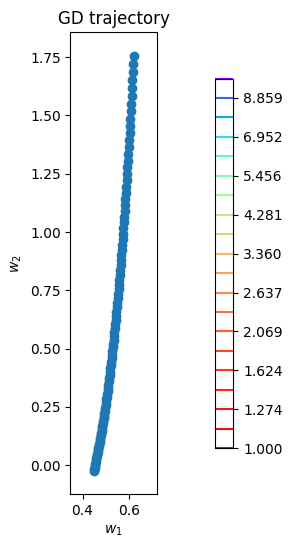

lr = 0.001


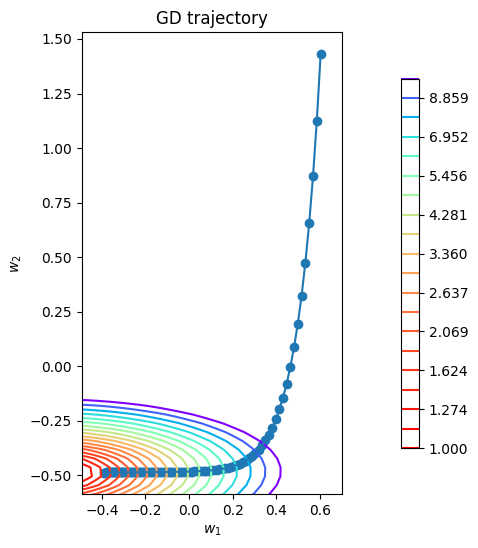

lr = 0.01


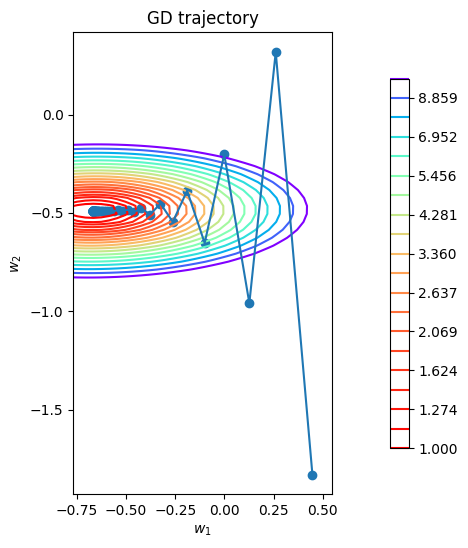

lr = 0.05


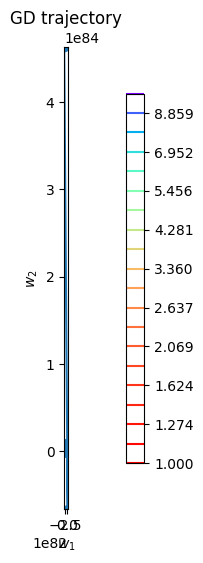

In [14]:
lr_values = [0.0001, 0.001, 0.01, 0.05]

loss = MSELoss()

for lr in lr_values:
    print(f"lr = {lr}")
    w_list = gradient_descent(
        w_init=w_init,
        X=X,
        y=y,
        loss=loss,
        lr=lr,
        n_iterations=100
    )
    plot_gd(w_list, X, y, loss)

При очень маленьком lr примерно равным 0,0001 градиентный спуск движется очень медленно, при lr от 0,001 до 0,01 довольно быстро приближается к минимуму, при большом lr значение очень быстро увеличивается. Поэтому лучше брать средние значения lr.

1.4

In [15]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) -- начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) -- матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) -- вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float -- параметр величины шага, на который нужно домножать градиент
    :param batch_size: int -- размер подвыборки, которую нужно семплировать на каждом шаге
    :param n_iterations: int -- сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) -- история весов на каждом шаге
    """
    w = w_init.copy()
    w_history = []

    for _ in range(n_iterations):
        batch_indices = np.random.choice(
            X.shape[0],
            size=batch_size,
            replace=False
        )

        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        grad = loss.calc_grad(X_batch, y_batch, w)
        w = w - lr * grad

        w_history.append(w.copy())

    return w_history

1.5

lr = 0.0001, batch_size = 1


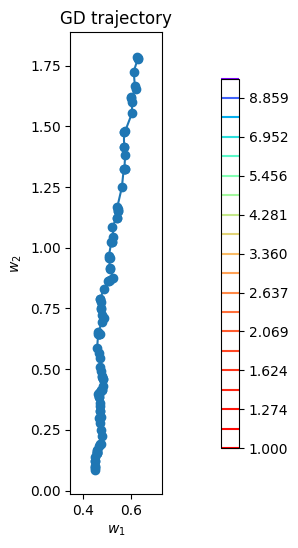

lr = 0.0001, batch_size = 10


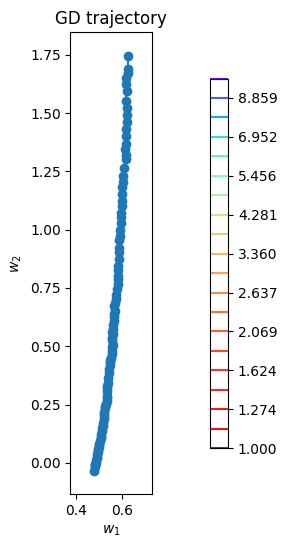

lr = 0.0001, batch_size = 50


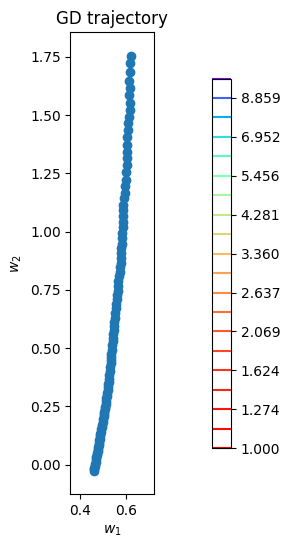

lr = 0.0001, batch_size = 150


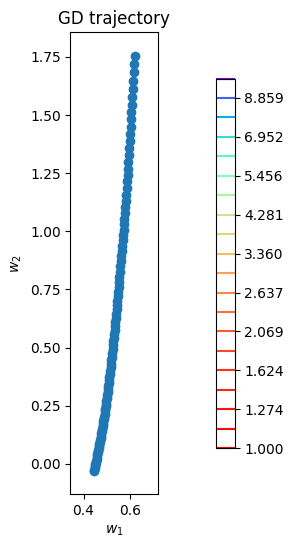

lr = 0.001, batch_size = 1


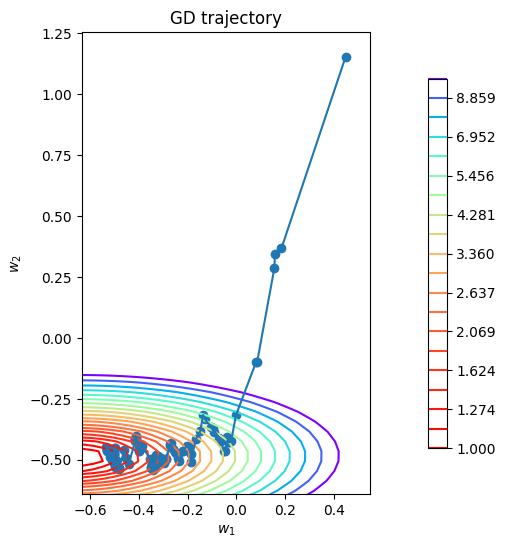

lr = 0.001, batch_size = 10


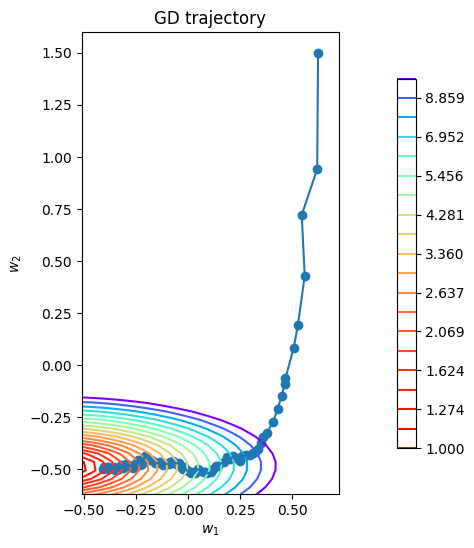

lr = 0.001, batch_size = 50


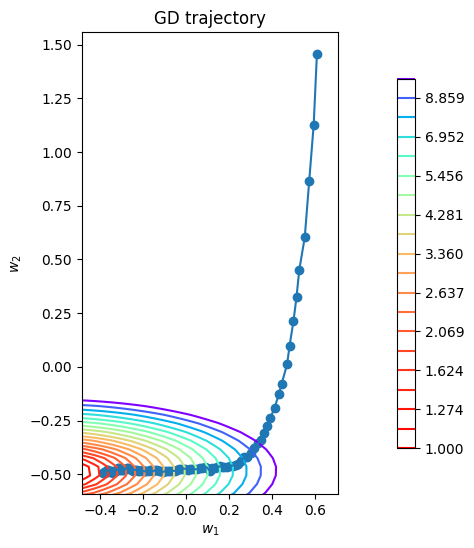

lr = 0.001, batch_size = 150


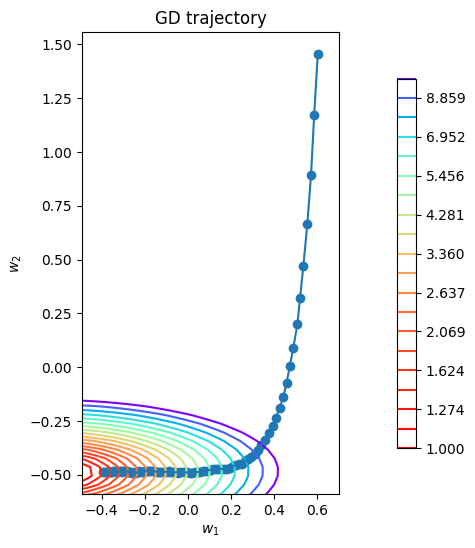

lr = 0.01, batch_size = 1


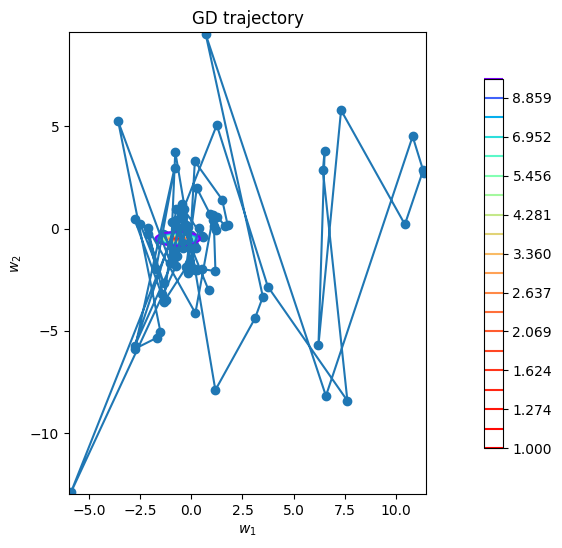

lr = 0.01, batch_size = 10


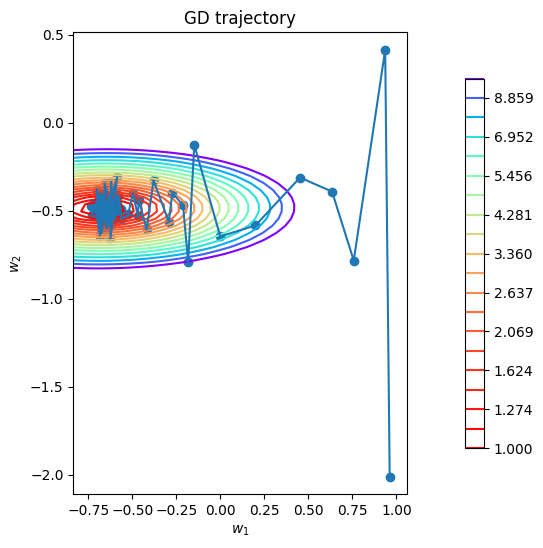

lr = 0.01, batch_size = 50


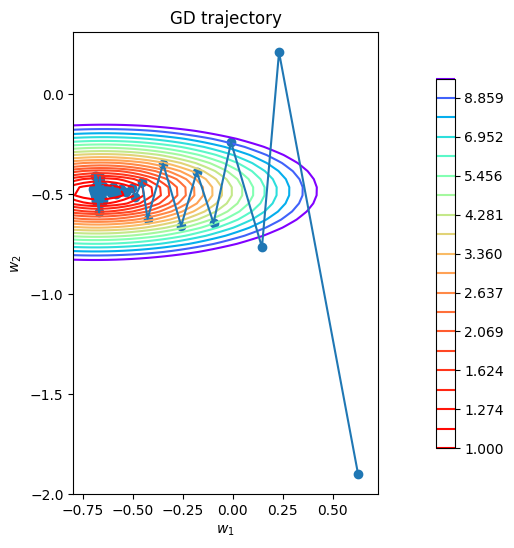

lr = 0.01, batch_size = 150


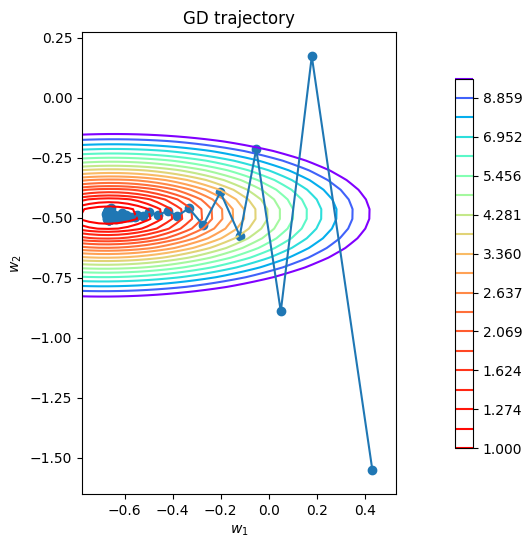

lr = 0.05, batch_size = 1


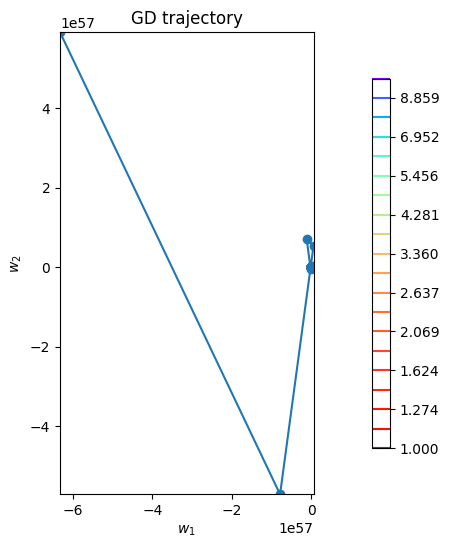

lr = 0.05, batch_size = 10


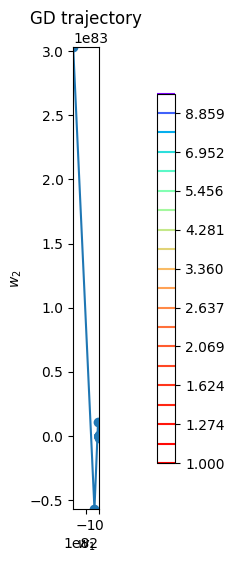

lr = 0.05, batch_size = 50


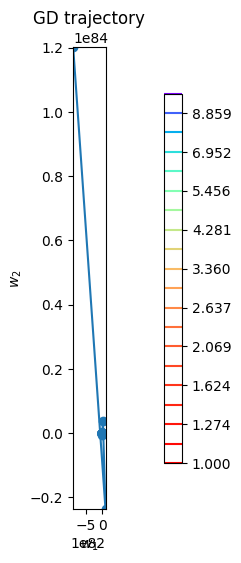

lr = 0.05, batch_size = 150


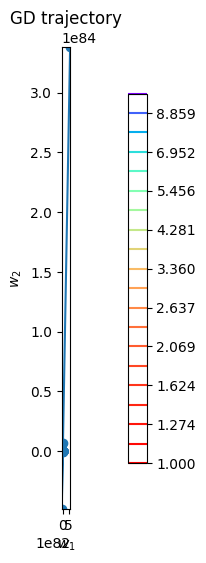

In [16]:
loss = MSELoss()

lr_values = [0.0001, 0.001, 0.01, 0.05]
batch_sizes = [1, 10, 50, 150]

for lr in lr_values:
    for batch_size in batch_sizes:
        print(f"lr = {lr}, batch_size = {batch_size}")

        w_list = stochastic_gradient_descent(
            w_init=w_init,
            X=X,
            y=y,
            loss=loss,
            lr=lr,
            batch_size=batch_size,
            n_iterations=100
        )

        plot_gd(w_list, X, y, loss)

Параметр lr влияет на размер шага: при маленьком значении градиентный спуск сходится медленно, а при слишком большом может колебаться и расходиться. Параметр batch_size влияет на точность градиента: при маленьком батче траектория шумная, но вычисления быстрее, а при большом движение стабильнее

Стохастический градиентный спуск отличается от обычного тем, что использует не всю выборку, а случайную подвыборку, поэтому работает быстрее

1.6

In [18]:
def stochastic_gradient_descent(
    w_init: np.ndarray,
    X: np.ndarray,
    y: np.ndarray,
    loss: BaseLoss,
    lr: float,
    batch_size: int,
    p: float,
    n_iterations: int = 1000,
) -> List[np.ndarray]:
    """
    Функция градиентного спуска
    :param w_init: np.ndarray размера (n_feratures,) - начальное значение вектора весов
    :param X: np.ndarray размера (n_objects, n_features) - матрица объекты-признаки
    :param y: np.ndarray размера (n_objects,) - вектор правильных ответов
    :param loss: Объект подкласса BaseLoss, который умеет считать градиенты при помощи loss.calc_grad(X, y, w)
    :param lr: float - параметр величины шага, на который нужно домножать градиент
    :param batch_size: int - размер подвыборки, которую нужно семплировать на каждом шаге
    :param p: float - значение степени в формуле затухания длины шага
    :param n_iterations: int - сколько итераций делать
    :return: Список из n_iterations объектов np.ndarray размера (n_features,) - история весов на каждом шаге
    """
    w = w_init.copy()
    w_history = []

    for t in range(1, n_iterations + 1):
        batch_indices = np.random.choice(
            X.shape[0],
            size=batch_size,
            replace=False
        )

        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        grad = loss.calc_grad(X_batch, y_batch, w)

        current_lr = lr / (t ** p)

        w = w - current_lr * grad

        w_history.append(w.copy())

    return w_history

1.7

p = 0.1


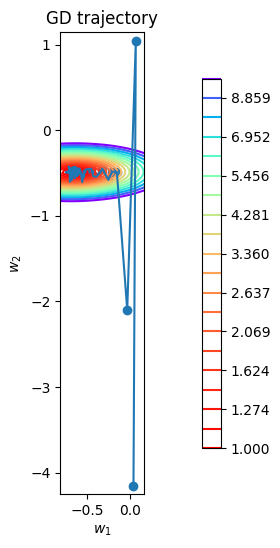

p = 0.3


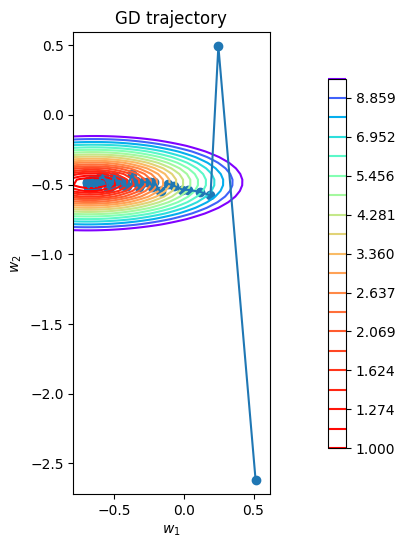

p = 0.5


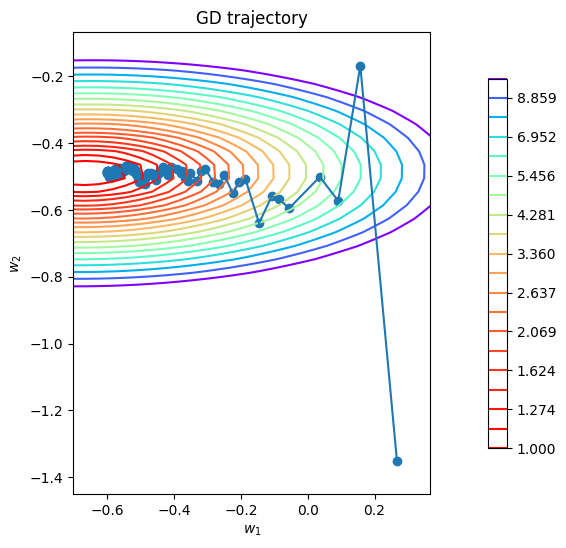

p = 1.0


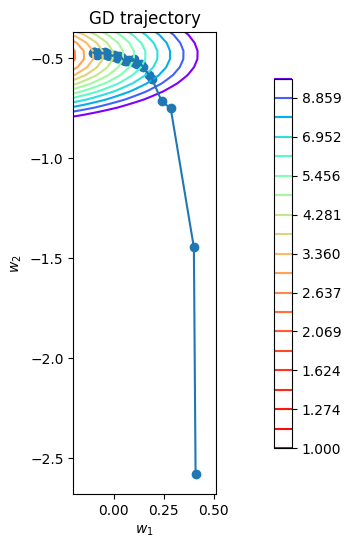

In [19]:
loss = MSELoss()

p_values = [0.1, 0.3, 0.5, 1.0]

for p in p_values:
    print(f"p = {p}")

    w_list = stochastic_gradient_descent(
        w_init=w_init,
        X=X,
        y=y,
        loss=loss,
        lr=0.01,
        batch_size=10,
        p=p,
        n_iterations=100
    )

    plot_gd(w_list, X, y, loss)

Параметр p определяет, как быстро уменьшается шаг обучения. При маленьком p шаг долго остаётся большим, поэтому спуск быстрее, но менее стабильный. При большом p шаг быстро уменьшается, движение становится плавнее, но сходимость может быть слишком медленной.

1.8

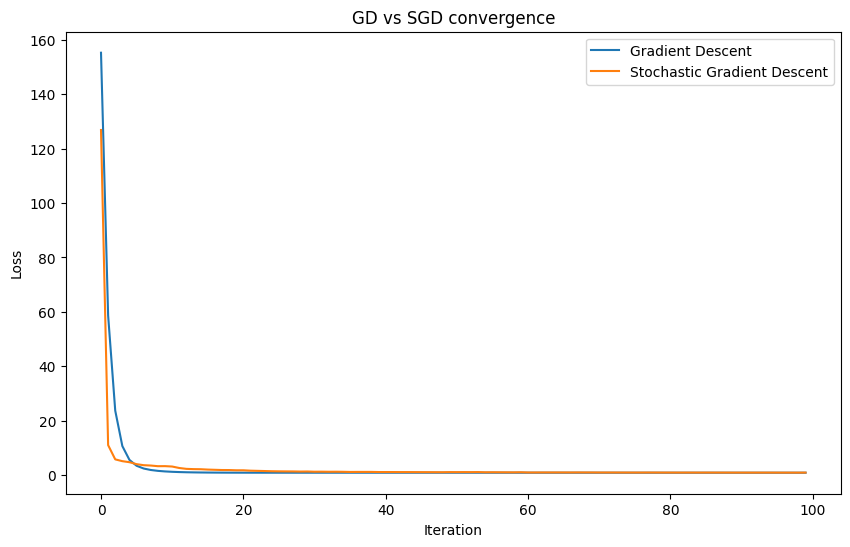

In [20]:
loss = MSELoss()

# GD
w_list_gd = gradient_descent(
    w_init=w_init,
    X=X,
    y=y,
    loss=loss,
    lr=0.01,
    n_iterations=100
)

# SGD
w_list_sgd = stochastic_gradient_descent(
    w_init=w_init,
    X=X,
    y=y,
    loss=loss,
    lr=0.01,
    batch_size=10,
    p=0.5,
    n_iterations=100
)

# значения лосса
gd_losses = [loss.calc_loss(X, y, w) for w in w_list_gd]
sgd_losses = [loss.calc_loss(X, y, w) for w in w_list_sgd]

plt.figure(figsize=(10, 6))

plt.plot(gd_losses, label="Gradient Descent")
plt.plot(sgd_losses, label="Stochastic Gradient Descent")

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("GD vs SGD convergence")
plt.legend()
plt.show()

Обычный градиентный спуск уменьшается плавнее и стабильнее

2.1

In [23]:
class LinearRegression:
    def __init__(self, loss: BaseLoss, lr: float = 0.1) -> None:
        self.loss = loss
        self.lr = lr

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegression":
        X = np.asarray(X)
        y = np.asarray(y)

        # столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        # веса
        w_init = np.zeros(X.shape[1])

        # градиентный спуск
        w_history = gradient_descent(
            w_init=w_init,
            X=X,
            y=y,
            loss=self.loss,
            lr=self.lr
        )

        self.w = w_history[-1]

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        # Проверяем, что регрессия обучена
        assert hasattr(self, "w"), "Linear regression must be fitted first"

        # Добавляем столбец из единиц для константного признака
        X = np.hstack([X, np.ones([X.shape[0], 1])])

        return X @ self.w

In [24]:
linear_regression = LinearRegression(MSELoss())

In [26]:
import pandas as pd

X_raw = pd.read_csv(
    "cars_data.csv",
    header=None,
    na_values=["?"],
    skiprows=1,
    index_col=0
)
X_raw = X_raw[~X_raw[26].isna()].reset_index(drop=True)
X_raw.head()

,1,2,3,4,5,6,7,8,9,10,...,17,18,19,20,21,22,23,24,25,26
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [27]:
y = X_raw[26]
X_raw = X_raw.drop(26, axis=1)